# Playground V1
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [1]:
import warnings

from typing import Callable, List, Optional, Tuple, Union

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.metrics import pairwise_distances


import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python


/Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'api', 'config', 'grids']
Classes: ['CARVE']
Functions: []


In [3]:
from carve import CARVE
from carve.config import ValidatorConfig

---

## 1. Data Simulation:

In [4]:
def _validate_center_box(center_box: float) -> float:
    if center_box < 0:
        warnings.warn('`center_box` should be positive; using abs(center_box).')
        center_box = -center_box
    if center_box == 0.0:
        warnings.warn('`center_box` was 0; defaulting to 10.0.')
        center_box = 10.0
    return center_box

def _lhs_centers(k: int, p: int, center_box: float, rng: np.random.Generator) -> np.ndarray:
    # latin hypercube: each dim gets a random permutation of k bins, with jitter inside each bin
    X = np.empty((k, p), dtype=float)
    
    for j in range(p):
        perm = rng.permutation(k)
        u = (perm + rng.random(k)) / k  # jitter inside each bin -> U(0,1)
        X[:, j] = -center_box + (2 * center_box) * u
        
    return X

def _best_candidate_centers(k: int, p: int, center_box: float, rng: np.random.Generator, n_candidates: int = 64) -> np.ndarray:
    centers = np.empty((k, p), dtype=float)
    centers[0] = rng.uniform(-center_box, center_box, size=p)
    
    for i in range(1, k):
        cands = rng.uniform(-center_box, center_box, size=(n_candidates, p))
        
        # compute squared distances to existing centers
        diffs = cands[:, None, :] - centers[None, :i, :]
        d2 = np.sum(diffs**2, axis=2)
        min_d2 = d2.min(axis=1)
        centers[i] = cands[np.argmax(min_d2)]
        
    return centers

def _min_dist_centers(k: int, p: int, center_box: float, rng: np.random.Generator, min_center_dist: float, max_tries: int = 200000) -> np.ndarray:
    centers = []
    tries = 0
    min2 = min_center_dist ** 2
    
    while len(centers) < k and tries < max_tries:
        c = rng.uniform(-center_box, center_box, size=p)
        if not centers:
            centers.append(c)
        else:
            cc = np.vstack(centers)
            if np.all(np.sum((cc - c) ** 2, axis=1) >= min2):
                centers.append(c)
        tries += 1
        
    if len(centers) < k:
        raise ValueError(f"could not place {k} centers with min_center_dist={min_center_dist}. try reducing it or enlarging center_box.")
    
    return np.vstack(centers)

def _sample_cluster_sizes(
    n_total: int,
    k: int,
    rng: np.random.Generator,
    min_abs: int = 5,
    min_frac: float = 0.1,
    alpha: float | np.ndarray = 0.3,
    ensure_nonempty: bool = True
) -> np.ndarray:
    """
    Returns integer sizes summing to n_total with floors enforced.
    Strategy: allocate the guaranteed minimum first, then distribute the remainder
    via Multinomial with probabilities from a Dirichlet(alpha).
    """
    if n_total <= 0 or k <= 0:
        raise ValueError("n_total and k must be positive.")
    if min_abs < 0 or min_frac < 0:
        raise ValueError("min_abs and min_frac must be nonnegative.")
    if isinstance(alpha, np.ndarray) and alpha.shape != (k,):
        raise ValueError("alpha must be scalar or shape (k,).")

    # per-cluster floor
    floor_each = max(min_abs, int(np.ceil(min_frac * n_total)))
    if ensure_nonempty:
        floor_each = max(floor_each, 1)

    total_floor = floor_each * k
    if total_floor > n_total:
        raise ValueError(
            f"Infeasible: k * floor_each = {k} * {floor_each} = {total_floor} > n_total = {n_total}. "
            "Reduce k / floors or increase n_total."
        )

    # assign floors, then distribute the remainder
    sizes = np.full(k, floor_each, dtype=int)
    remaining = n_total - total_floor
    if remaining == 0:
        return sizes

    # Dirichlet probs -> Multinomial integer split
    a = np.full(k, alpha, dtype=float) if np.isscalar(alpha) else alpha.astype(float)
    probs = rng.dirichlet(a)
    sizes += rng.multinomial(remaining, probs)
    return sizes

In [5]:
def simulate_clusters(
    n_total: int,
    p: int,
    k: int,
    cluster_scale: Union[float, List[float], Callable[[], float]] = 1.0,
    balanced: bool = True,
    cluster_sizes_frac: Optional[List[float]] = None,
    min_cluster_size_abs: int = 5, 
    min_cluster_size_frac: float = 0.1, 
    cluster_size_dirichlet_alpha: float | np.ndarray = 0.3,
    corr_type: str = "none",
    corr_strength: float = 1.0,
    block_size: Optional[int] = None,
    outliers: Union[int, float] = 0,
    outlier_scale: float = 5.0,
    outlier_mode: str = "far_gaussian",
    distribution: str = "gaussian",
    t_df: int = 3,
    nonlinear: bool = False,
    embed_dim: Optional[int] = None,
    embed_method: str = "random_fourier",
    embed_param: float = 2.0,
    center_box: float = 10.0,
    centroid_method: str = "best_candidate",  # "none" | "lhs" | "best_candidate" | "min_dist"
    n_candidates: int = 64,
    min_center_dist: float | None = None,
    plotting: bool = True,
    random_state: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    simulate_clusters generates a synthetic dataset X (n_total × p) and 
    corresponding labels y (0..k-1 for clusters, -1 for outliers).

    :param n_total: total number of samples (including outliers)
    :param p: number of features
    :param k: number of clusters
    :param cluster_scale: overall spread parameter: 
        - single float → all clusters use σ² = cluster_scale 
        - list of length k → per-cluster σ² 
        - callable → draw σ² for each cluster via cluster_scale()
    :param balanced: if True, clusters are equal‐sized; else random (or via cluster_sizes)
    :param cluster_sizes_frac: array of cluster balances between 0 and 1, must sum to 1.
    :param corr_type: structure of within‐cluster covariance, one of: {"none", "ar1", "block"}
    :param corr_strength: ρ parameter for correlation (only used if corr_type ≠ "none")
    :param block_size: size of correlated blocks, only used if corr_type = "block"
    :param outliers: if int → number of outliers; if float in (0,1) → fraction of n_total
    :param outlier_scale: distance multiplier for placing outliers from global centroid
    :param outlier_mode: sampling strategy for outliers
    :param distribution: base distribution for cluster sampling
    :param t_df:
    :param nonlinear:
    :param embed_dim:
    :param enbed_method:
    :param center_box: bound for hyper-cube from which centroids are centered
    :param random_state: seed for reproducibility

    :return (X, y): tuple of np.ndarray, shape (n_total, p) and np.ndarray, shape (n_total, )
    """
    rng = np.random.default_rng(seed=random_state)
    
    # determine number of outliers
    if isinstance(outliers, float) and 0 < outliers < 1:
        n_outliers = np.floor(n_total * outliers)
    elif isinstance(outliers, int):
        n_outliers = outliers
    else:
        n_outliers = 0
        warnings.warn("`outliers` must be a non-negative int or a float in (0, 1). Defaulting to n_outliers = 0.")
    
    # consider total number of points to be clustered 
    n_total_clusters = n_total - n_outliers
    if n_total_clusters < 1:
        raise ValueError("`outliers` too large, no points left for clusters.")
    
    # handle cluster balancing
    if cluster_sizes_frac is not None:
        if len(cluster_sizes_frac) != k:
            raise ValueError(f"cluster_sizes_frac must have length k={k}.")
        total = float(np.sum(cluster_sizes_frac))
        if abs(total - 1.0) > 1e-8:
            warnings.warn('`cluster_sizes_frac` does not add up to 1. Rescaling cluster_sizes_frac.')
            total = np.sum(cluster_sizes_frac)
            cluster_sizes_frac = [frac / total for frac in cluster_sizes_frac]
        cluster_sizes = [int(np.floor(n_total_clusters * frac)) for frac in cluster_sizes_frac]
        for i in range(n_total_clusters - np.sum(cluster_sizes)):
            cluster_sizes[i % k] += 1
    elif balanced: 
        base_cluster_size = n_total_clusters // k
        cluster_sizes = [base_cluster_size] * k
        for i in range(n_total_clusters - (base_cluster_size * k)):
            cluster_sizes[i] += 1
    else:
        cluster_sizes = _sample_cluster_sizes(
            n_total=n_total, 
            k=k, 
            rng=rng, 
            min_abs=min_cluster_size_abs, 
            min_frac=min_cluster_size_frac, 
            alpha=cluster_size_dirichlet_alpha
        )
    
    assert np.sum(cluster_sizes) == n_total_clusters
    
    # sample cluster centers
    center_box = _validate_center_box(center_box)
    
    if centroid_method == "none":
        centers = rng.uniform(-center_box, center_box, size=(k, p))
    elif centroid_method == "lhs":
        centers = _lhs_centers(k, p, center_box, rng)
    elif centroid_method == "best_candidate":
        centers = _best_candidate_centers(k, p, center_box, rng, n_candidates=n_candidates)
    elif centroid_method == "min_dist":
        if min_center_dist is None:
            # default: ~5% of the hypercube diagonal
            diag = 2 * center_box * np.sqrt(p)
            min_center_dist = 0.05 * diag
        centers = _min_dist_centers(k, p, center_box, rng, min_center_dist=min_center_dist)
    else:
        raise ValueError(f"unknown centroid_method: {centroid_method}")
    
    # get per‐cluster scale values
    if callable(cluster_scale):
        cluster_scales = [cluster_scale() for _ in range(k)]
    elif isinstance(cluster_scale, list):
        if len(cluster_scale) != k: 
            raise ValueError('Passed `cluster_scale` parameter must be of size k.')
        cluster_scales = cluster_scale
    else:
        cluster_scales = [cluster_scale] * k
        
    # handle correlation
    if corr_type == 'none':
        R = np.eye(p)
    elif corr_type == 'ar1':
        R = np.fromfunction(
            lambda i, j: corr_strength ** np.abs(i-j), 
            (p, p),
            dtype=float
        )
    elif corr_type:
        if block_size is None:
            raise ValueError("`block_size` must be provided when corr_type='block'")
        R = np.zeros((p, p))
        for start in range(0, p, block_size):
            end = min(start + block_size, p)
            R[start:end, start:end] = corr_strength
        np.fill_diagonal(R, 1.0)
    else:
        raise ValueError(f"Unknown corr_type `{corr_type}`")

    covs = [scale * R for scale in cluster_scales]
    
    # sample X
    X_parts, y_parts = [], []
    
    for c in range(k):
        size = cluster_sizes[c]
        mean = centers[c]
        cov = covs[c]
        
        if distribution == "gaussian":
            X_c = rng.multivariate_normal(mean=mean, cov=cov, size=size)
        elif distribution == "t":
            # multivariate t:  X = μ + L z * sqrt(df / v), z~N(0,I), v~χ²(df)
            df = t_df
            L = np.linalg.cholesky(cov)
            z = rng.standard_normal((size, p))
            v = rng.chisquare(df, size=(size, 1))
            X_c = mean + (z @ L.T) * np.sqrt(df / v)
        elif distribution == 'uniform_ball':
            # sample uniform in p-ball of radius = √(trace(Σ)/p)
            r_max = np.sqrt(np.trace(cov) / p)
            U = rng.standard_normal((size, p))
            U /= np.linalg.norm(U, axis=1, keepdims=True)
            radii = rng.random(size) ** (1/p) * r_max
            X_c = mean + U * radii.reshape(-1, 1)
        else:
            raise ValueError("`distribution` must be one of: {\"gaussian\", \"t\", or \"uniform_ball\"}.")
        
        X_parts.append(X_c)
        y_parts.append(np.full(cluster_sizes[c], c, dtype=int))
        
    # sample outliers
    if n_outliers > 0:
        global_centroid = np.average(centers, axis=0, weights=cluster_sizes)
        
        avg_cov = np.sum(cluster_sizes[c] * covs[c] for c in range(k)) / np.sum(cluster_sizes)
        global_sigma = np.sqrt(np.mean(np.diag(avg_cov)))
        
        if outlier_mode == 'far_gaussian':
            U = rng.standard_normal(size=(n_outliers, p))
            U /= np.linalg.norm(U, axis=1, keepdims=True)
            X_out = global_centroid + outlier_scale * global_sigma * U
        elif outlier_mode == 'uniform_box':
            box = center_box * outlier_scale
            X_out = rng.uniform(-box, +box, size=(n_outliers, p))
        else:
            raise ValueError(f"unknown outlier_mode `{outlier_mode}`")

        X_parts.append(X_out)
        y_parts.append(np.full(n_outliers, -1, dtype=int))
        
    # concatenate and shuffle        
    X = np.vstack(X_parts)  # shape (n_total, p)
    y = np.concatenate(y_parts)  # shape (n_total,)

    perm = rng.permutation(len(y))
    X = X[perm]
    y = y[perm]
    
    if nonlinear:
        if embed_method == 'fourier':
            freq_scale = 0.1  
            W = rng.normal(scale=freq_scale, size=(p, embed_dim))
            b = rng.uniform(0, 2*np.pi, size=(embed_dim,))
            X = np.sin(X @ W + b)
        elif embed_method == 'poly':
            d = embed_param
            X = np.hstack([
                X,
                X**d,
                (X[:, [0]] * X[:, [1]]),
            ])
        elif embed_method == 'rbf':
            sigma_rbf = embed_param
            
            prototypes = X[rng.choice(len(X), size=50, replace=False)]
            gamma = 1.0 / (2 * sigma_rbf**2)
            X = np.exp(-gamma * ((X[:,None,:] - prototypes[None,:,:])**2).sum(-1))
    
    # visualize
    if plotting:
        pca = PCA(n_components=2, random_state=random_state)
        X_pca = pca.fit_transform(X)

        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(
            X_pca[:, 0], X_pca[:, 1],
            c=y, cmap='tab10', edgecolors='k', alpha=0.8
        )
        plt.title("PCA projection of simulated clusters")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    uncert = None
    return X, y, uncert

---

## 2. Benchmarking

In [6]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_59141/2337443590.py:81: UserWarning: `cluster_sizes_frac` does not add up to 1. Rescaling cluster_sizes_frac.
  warnings.warn('`cluster_sizes_frac` does not add up to 1. Rescaling cluster_sizes_frac.')


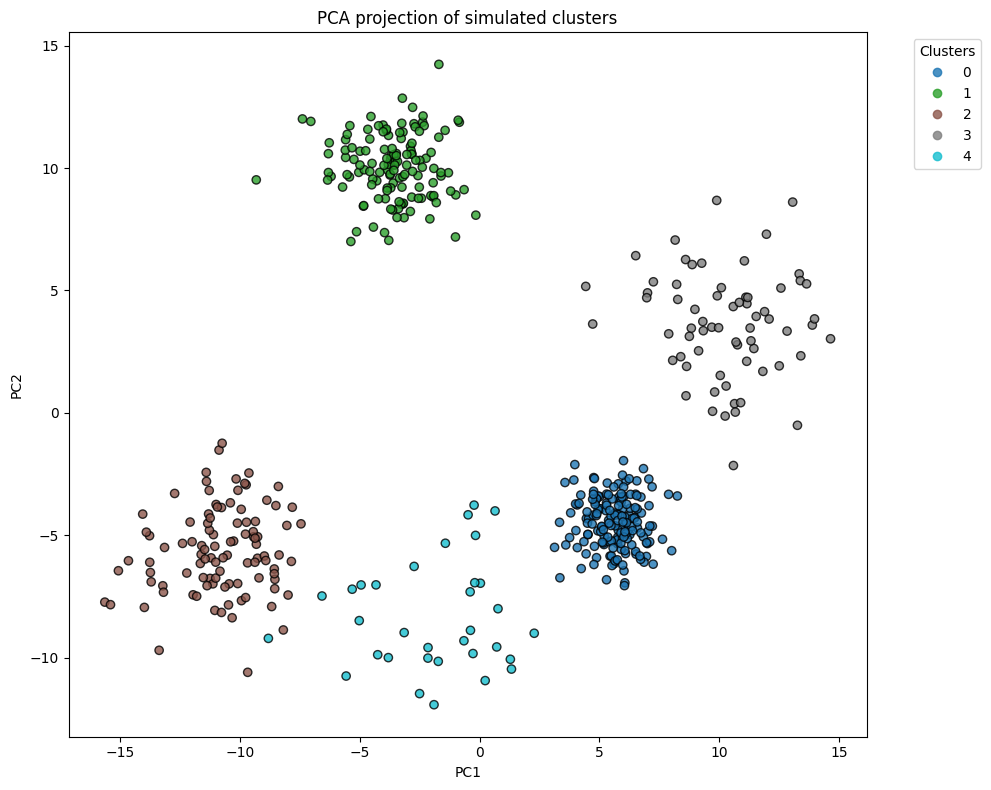

In [8]:
k1 = 5
sizes1 = list(range(k1, 0, -1))
scales1 = [1 * s for s in list(range(1, k1+1))]

X1, y1, _ = simulate_clusters(
    n_total=500, p=2, k=k1, balanced=False,
    cluster_sizes_frac=sizes1,
    cluster_scale=scales1,
    random_state=42
)

In [ ]:
D2_1 = pairwise_distances(X1, metric='sqeuclidean')
median_d2_1 = np.median(D2_1[np.triu_indices_from(D2_1, k=1)])
gamma0_1 = 1.0 / (2.0 * median_d2_1) if median_d2_1 > 0 else 1.0

ks = list(range(2, 9))
    
model_grids1 = [
    (KMeans, {"n_clusters": ks}),
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    (SpectralClustering, {"n_clusters": ks, "gamma": [gamma0_1]})
]

cfg1 = ValidatorConfig(
    X=X1,
    ref_labels=y1,
    model_grids=model_grids1
)

val1 = CARVE(cfg1)
val1.validate(random_state=42)

Grid configs: 100%|██████████| 21/21 [00:28<00:00,  1.35s/it]


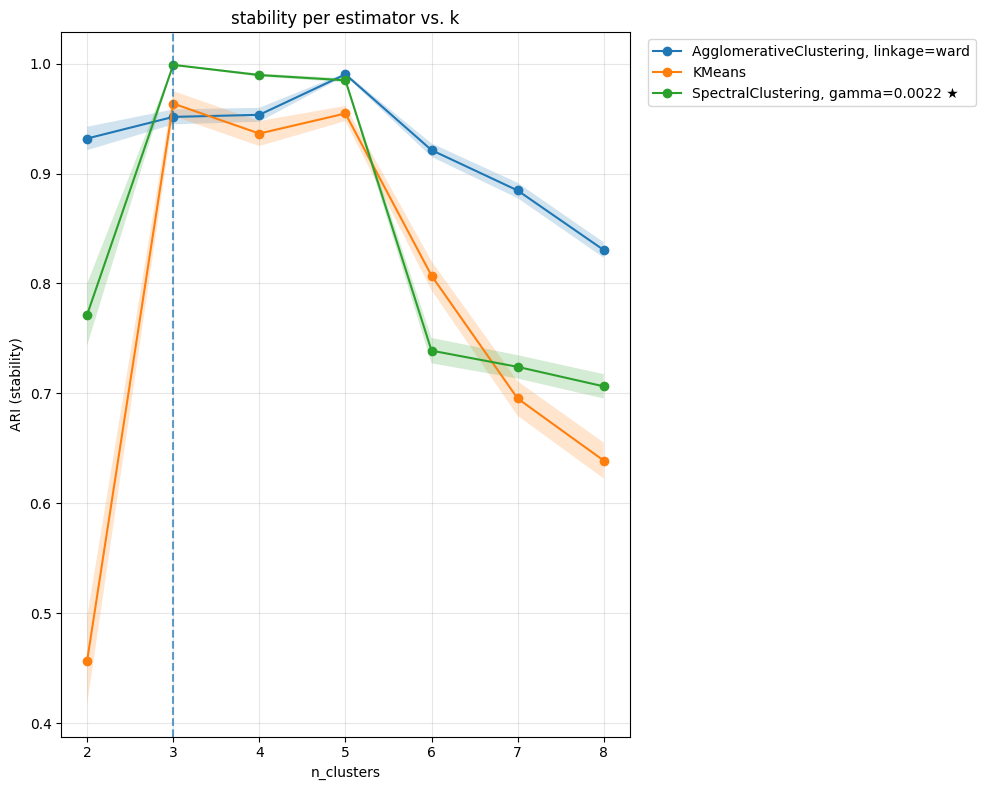

In [17]:
val1.plot_global(measure='stability', rule='1se')

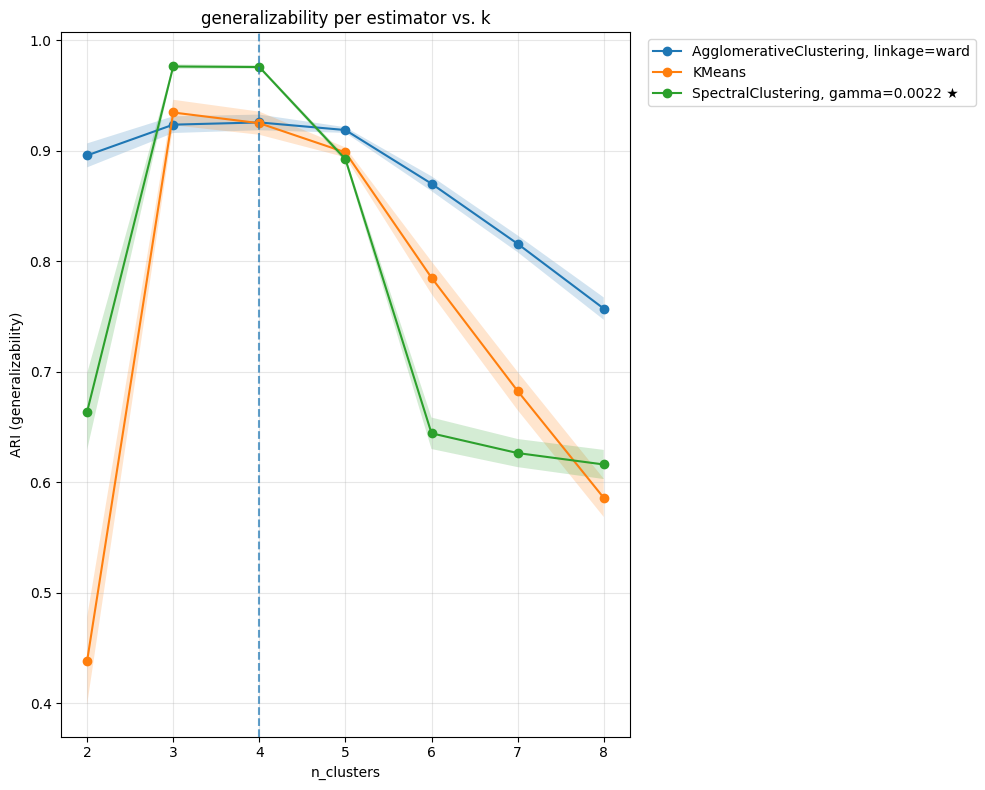

In [18]:
val1.plot_global(measure='generalizability', rule='1se')

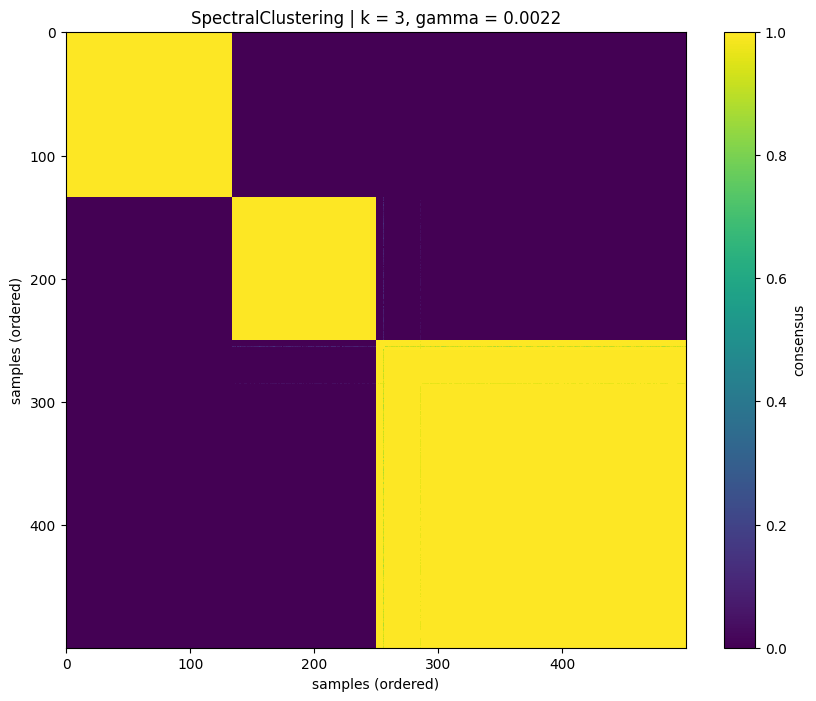

In [23]:
val1.plot_consensus_matrix(measure='stability', rule='1se')

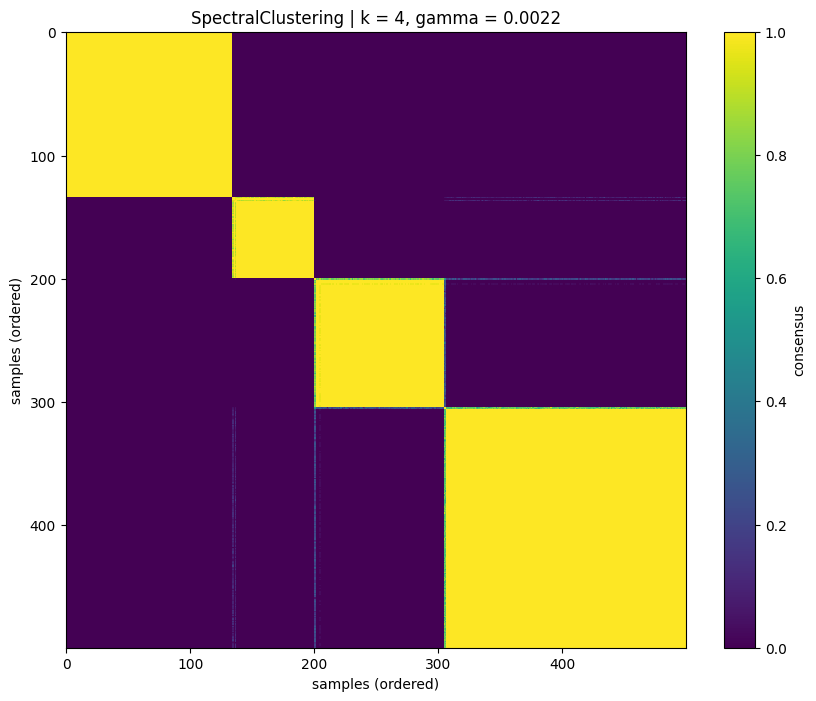

In [24]:
val1.plot_consensus_matrix(measure='g', rule='1se')

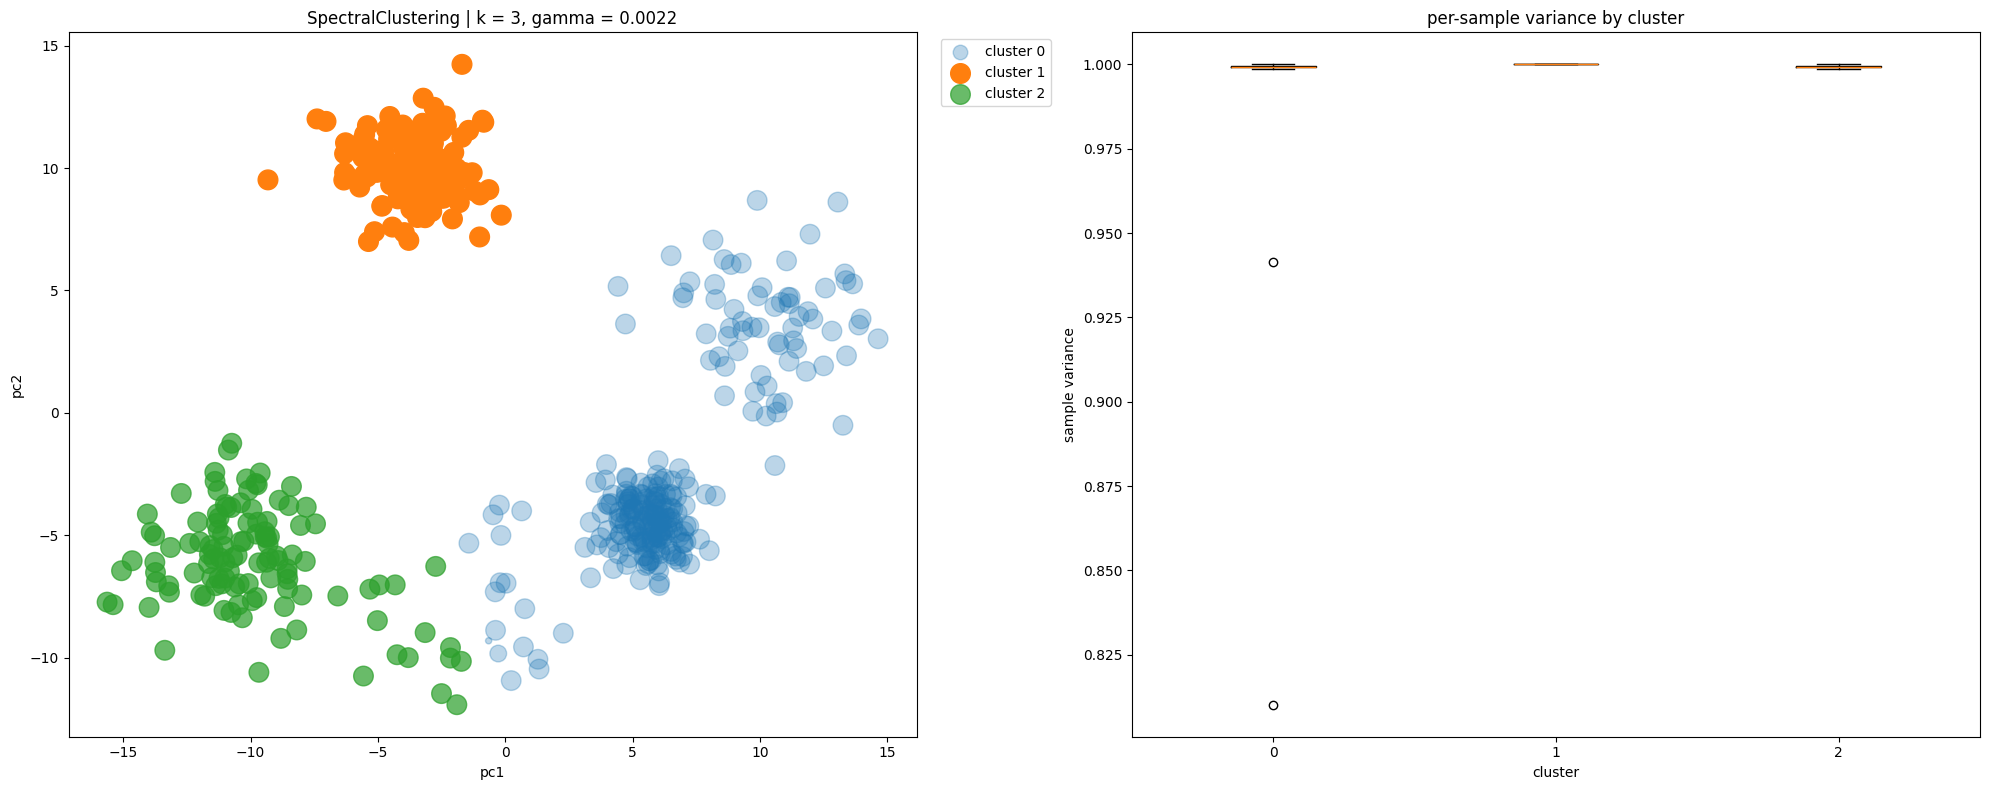

In [25]:
val1.plot_clustering(measure='s', rule='1se')

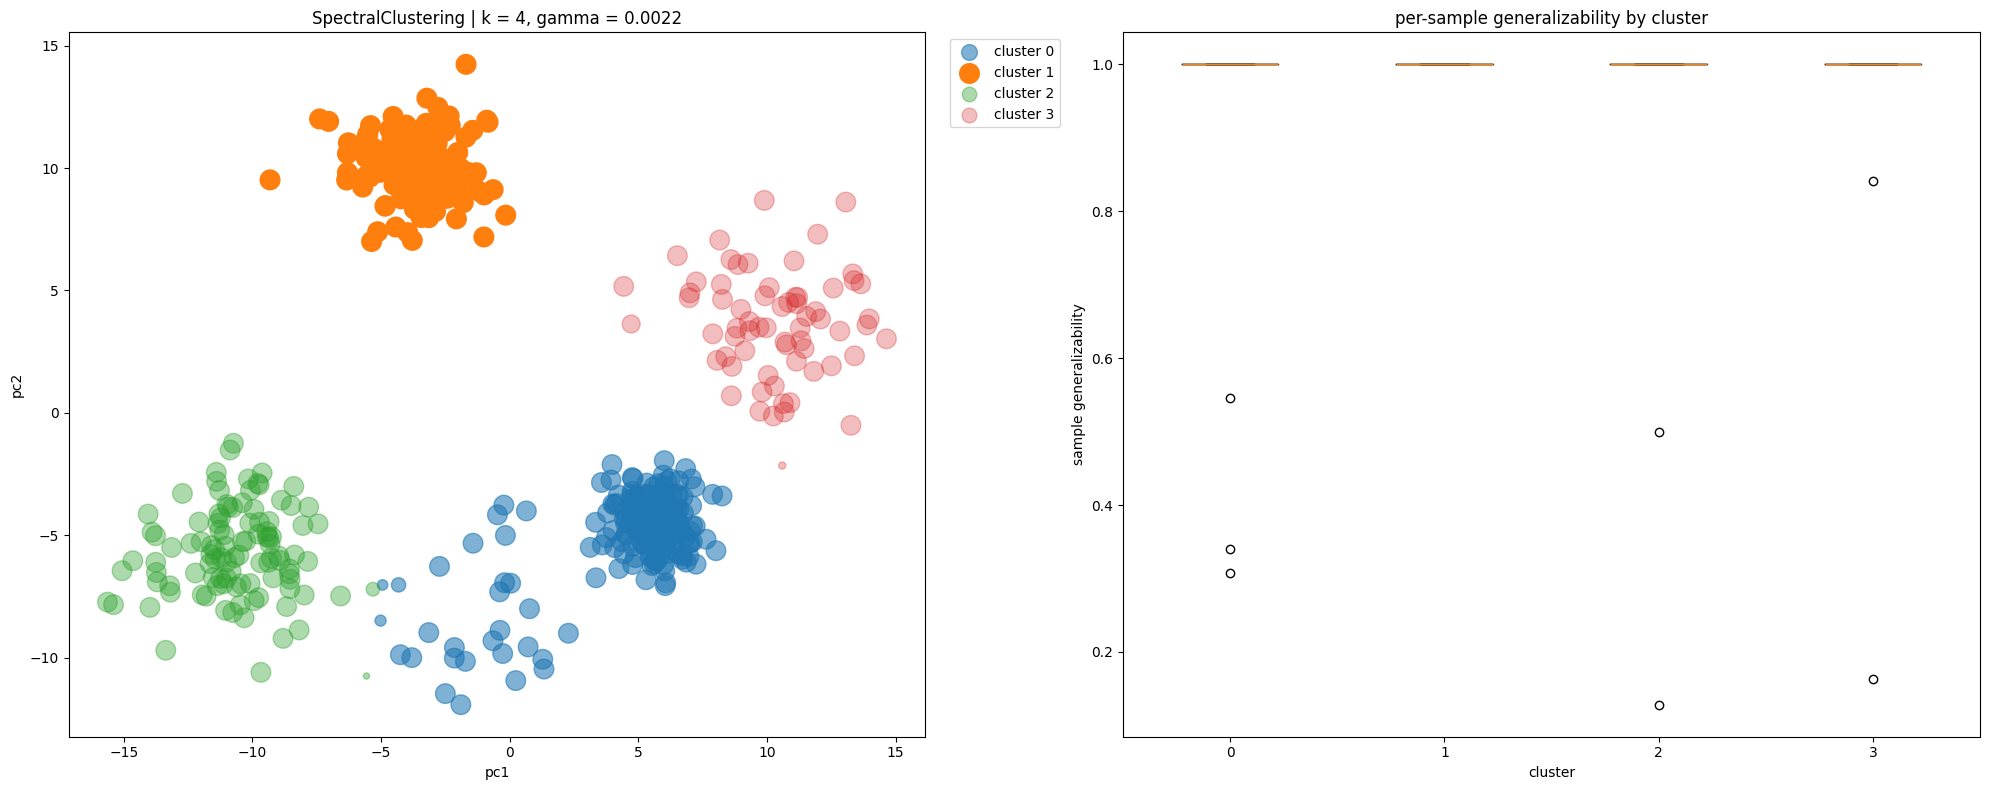

In [26]:
val1.plot_clustering(measure='g', rule='1se')

---

/var/folders/l_/sb8sl5s14cxc7f15c67l1lg00000gn/T/ipykernel_59141/2337443590.py:81: UserWarning: `cluster_sizes_frac` does not add up to 1. Rescaling cluster_sizes_frac.
  warnings.warn('`cluster_sizes_frac` does not add up to 1. Rescaling cluster_sizes_frac.')


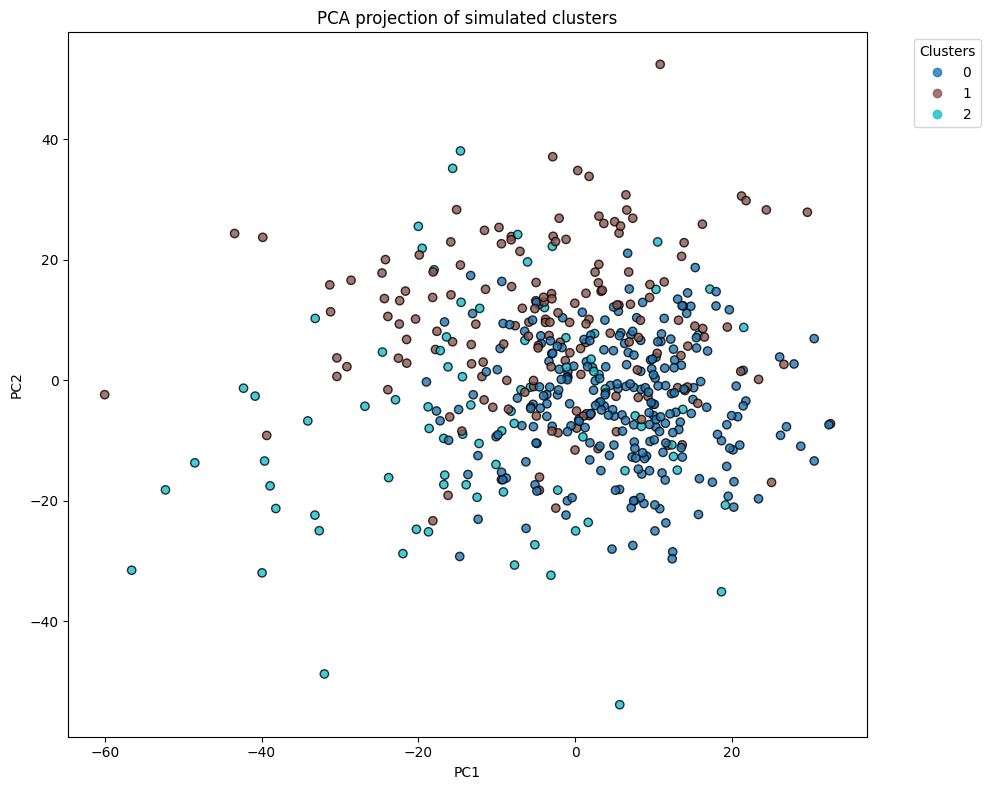

In [ ]:
k2 = 3

sizes2 = list(range(k2, 0, -1))
scales2 = [100 * s for s in list(range(1, k2+1))]

X2, y2, _ = simulate_clusters(
    n_total=500, p=2, k=k2, balanced=False,
    cluster_sizes_frac=sizes2,
    cluster_scale=scales2,
    random_state=42
)

In [28]:
D2_2 = pairwise_distances(X2, metric='sqeuclidean')
median_d2_2 = np.median(D2_2[np.triu_indices_from(D2_2, k=1)])
gamma0_2 = 1.0 / (2.0 * median_d2_2) if median_d2_2 > 0 else 1.0

ks2 = list(range(2, 9))
    
model_grids2 = [
    (KMeans, {"n_clusters": ks2}),
    (AgglomerativeClustering, {"n_clusters": ks2, "linkage": ["ward"]}),
    (SpectralClustering, {"n_clusters": ks2, "gamma": [gamma0_2]})
]

cfg2 = ValidatorConfig(
    X=X2,
    ref_labels=y2,
    model_grids=model_grids2
)

val1 = CARVE(cfg2)
val1.validate(random_state=42)

Grid configs: 100%|██████████| 21/21 [00:29<00:00,  1.39s/it]


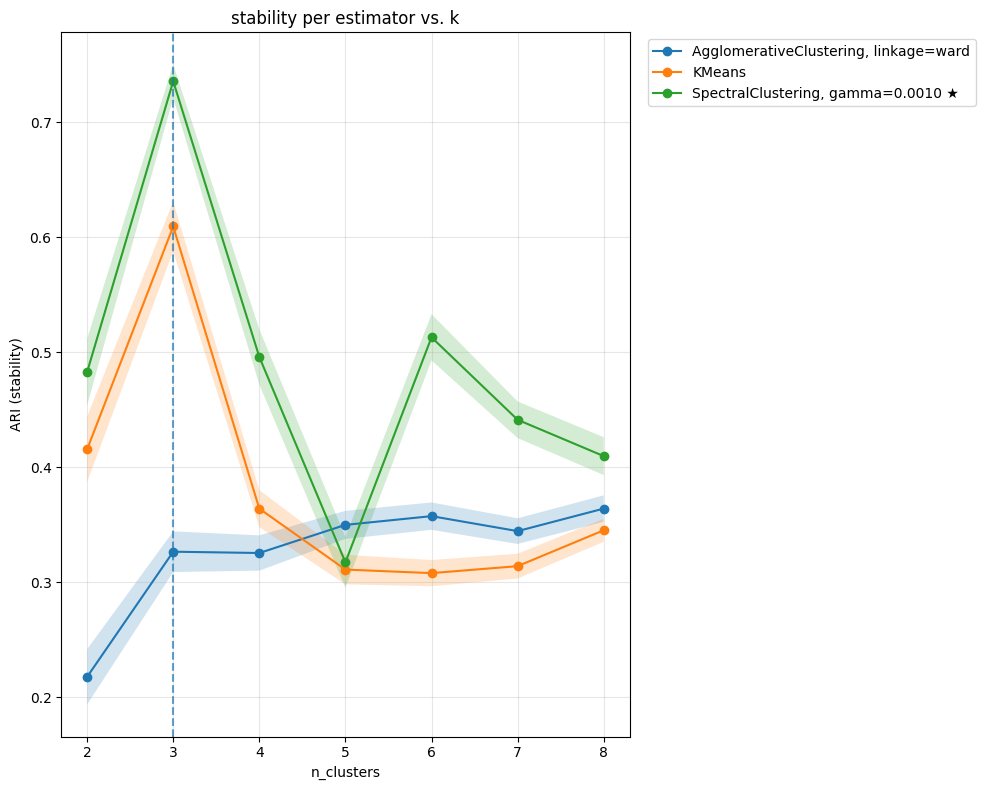

In [29]:
val1.plot_global(measure='stability', rule='1se')

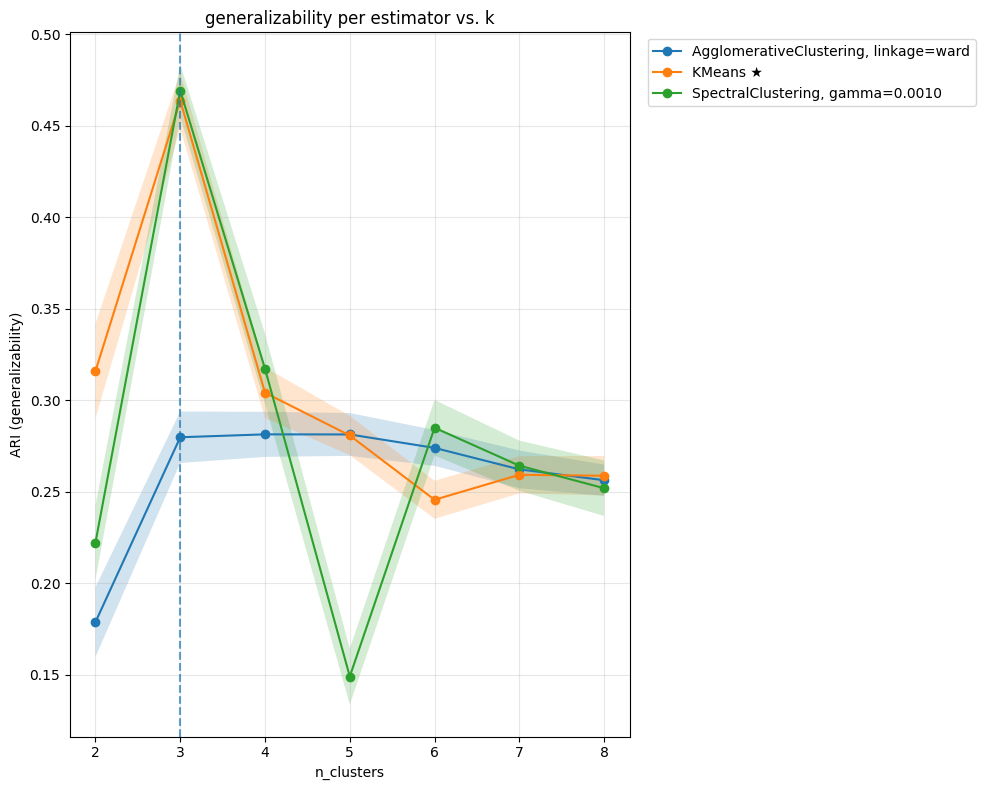

In [30]:
val1.plot_global(measure='generalizability', rule='1se')

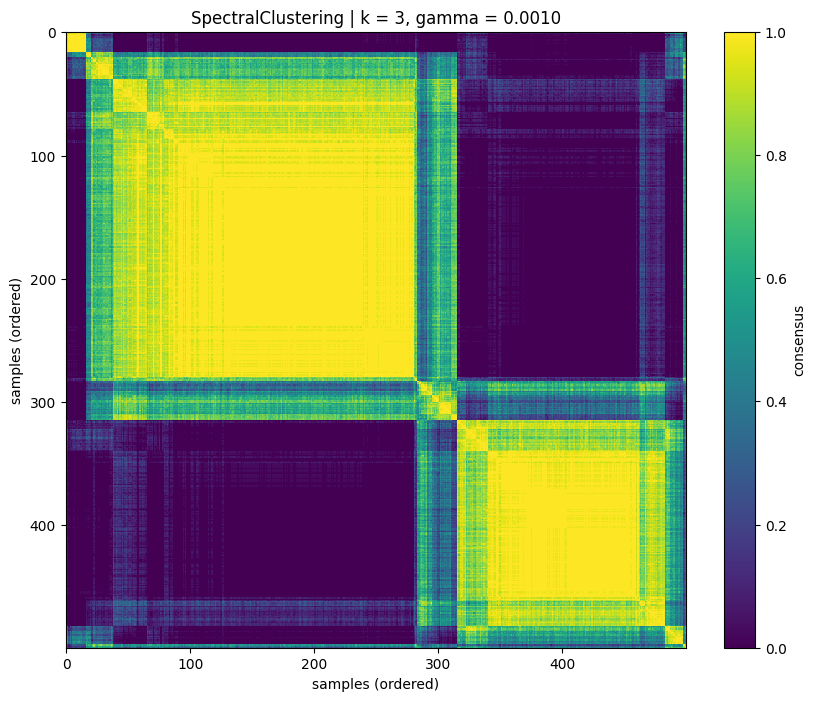

In [31]:
val1.plot_consensus_matrix(measure='stability', rule='1se')

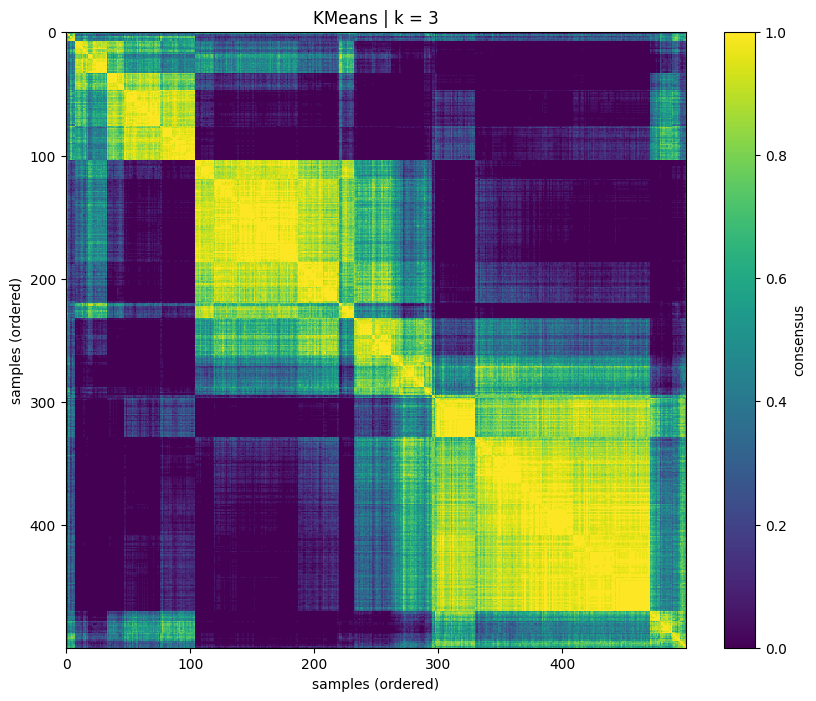

In [32]:
val1.plot_consensus_matrix(measure='g', rule='1se')

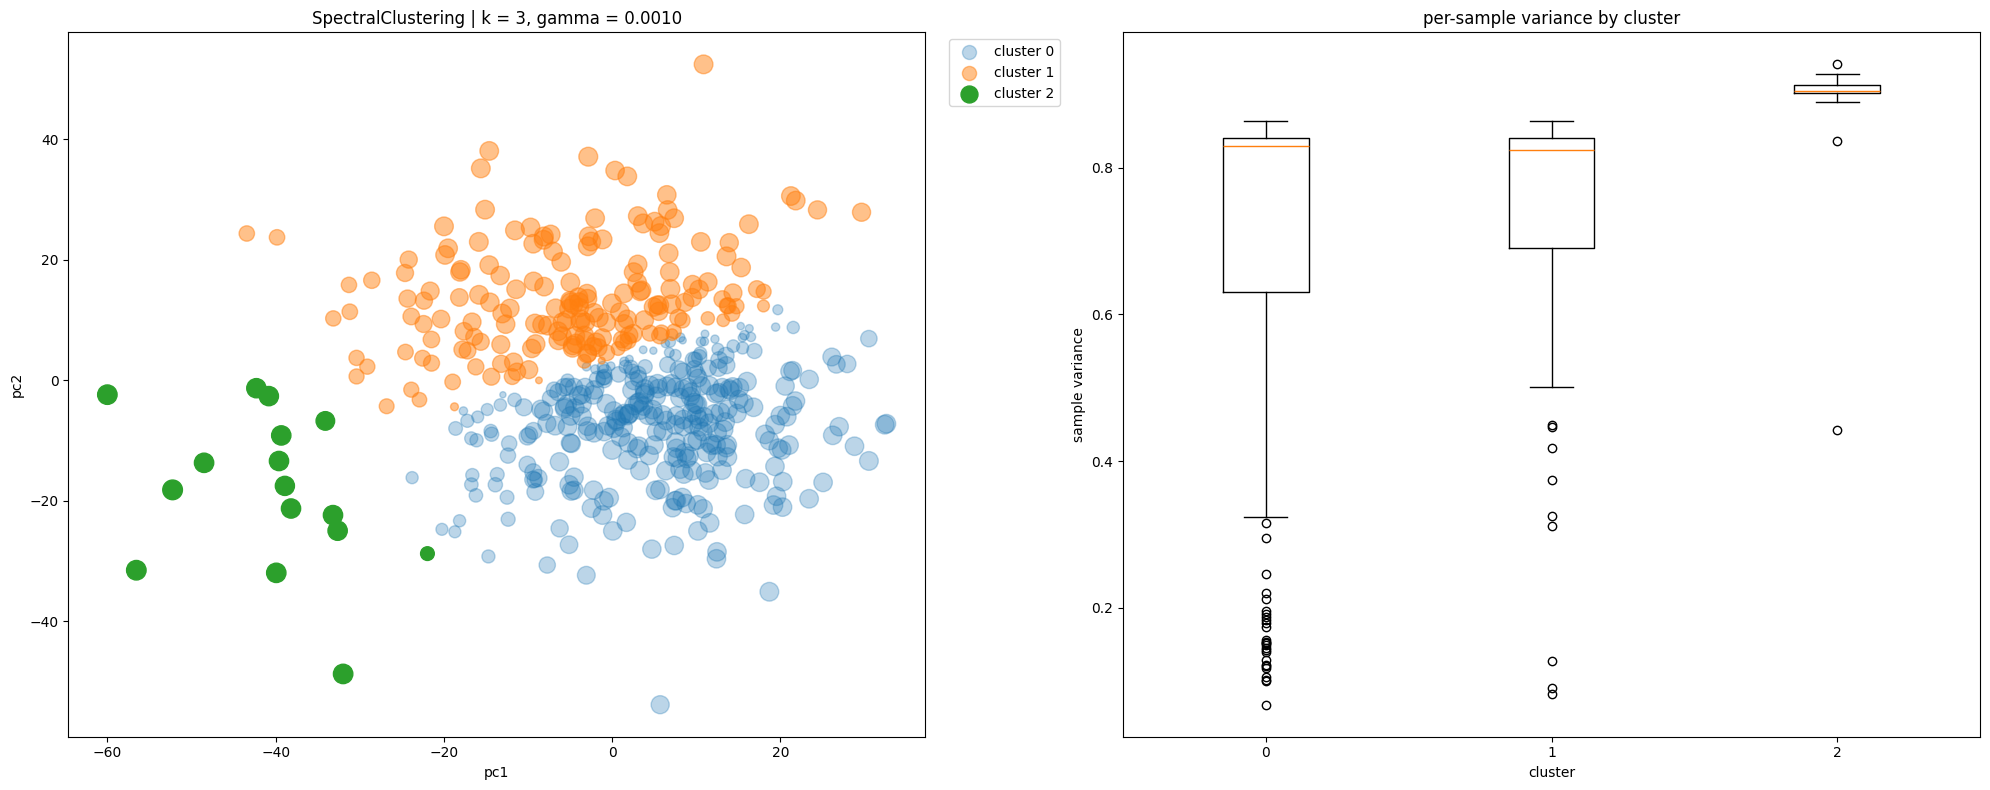

In [33]:
val1.plot_clustering(measure='s', rule='1se')

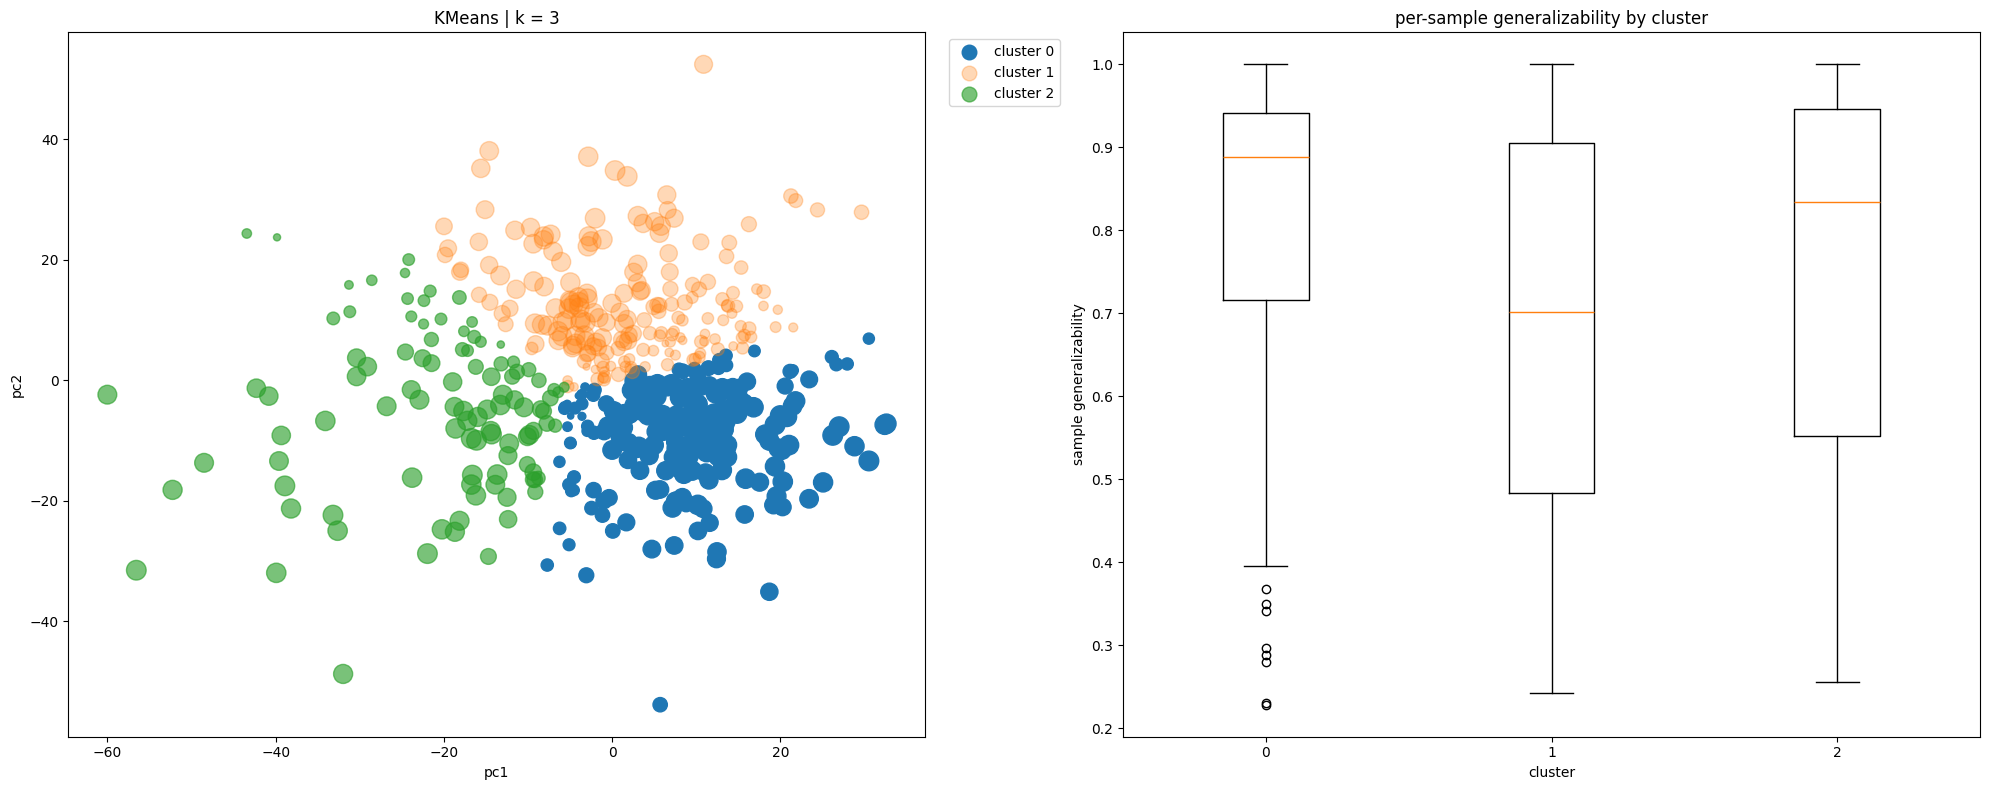

In [34]:
val1.plot_clustering(measure='g', rule='1se')